# Neural Architecture Search with Reinforcement Learning
## Replication of Zoph & Le (2017)

This notebook orchestrates the entire replication of the paper:
- **CIFAR-10** : search for convolutional architectures
- **Penn Treebank** : search for recurrent cells
- **Comparison NAS vs Random Search**
- **Visualizations** (Figures 6, 7, 8 of the paper)

# Imports and environment configuration

In [1]:
import os
import sys
import json
import time
import numpy as np
import torch

# Add project modules to the path
sys.path.insert(0, os.getcwd())

Device utilisé : cuda
PyTorch version : 2.7.1+cu118
GPU : NVIDIA GeForce RTX 2060
VRAM disponible : 6.0 GB


In [ ]:
# GPU check
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used: {device}")
print(f"PyTorch version: {torch.__version__}")

if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Available VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: GPU not available. Training will be very slow.")

# Loading configurations

In [2]:
from configs.cifar10_config import CIFAR10_CONFIG
from configs.ptb_config import PTB_CONFIG

print("CIFAR-10 CONFIGURATION")
print("-" * 60)
for k, v in CIFAR10_CONFIG.items():
    print(f"  {k:<40} : {v}")

print()
print("PTB CONFIGURATION")
print("-" * 60)
for k, v in PTB_CONFIG.items():
    print(f"  {k:<40} : {v}")

CONFIGURATION CIFAR-10
  controller_num_layers                    : 2
  controller_hidden_units                  : 35
  controller_lr                            : 0.0006
  controller_weight_init                   : (-0.08, 0.08)
  controller_optimizer                     : adam
  num_param_server_shards                  : 20
  num_controller_replicas                  : 100
  num_child_replicas                       : 8
  child_epochs                             : 50
  child_lr                                 : 0.1
  child_weight_decay                       : 0.0001
  child_momentum                           : 0.9
  child_optimizer                          : momentum_nesterov
  child_lr_decay_schedule                  : True
  reward_fn                                : max_val_acc_last5_cubed
  val_size                                 : 5000
  train_size                               : 45000
  filter_heights                           : [1, 3, 5, 7]
  filter_widths                       

# CIFAR-10

---
## 1. CIFAR-10 — Search for Convolutional Architectures

### Pipeline :
1. Data loading and preprocessing (ZCA whitening, crop, flip)
2. Initialization of the RNN controller (2-layer LSTM, 35 hidden units)
3. NAS search loop with REINFORCE
4. Final evaluation of the best architecture
5. Comparison with random search

# CIFAR-10 data loading

In [3]:
from utils.data_loader import get_cifar10_loaders

print("Loading CIFAR-10 data")
print("Preprocessing: ZCA whitening + upsample 40x40 + random crop 32x32 + random hflip")
print()

train_loader_cifar, val_loader_cifar, test_loader_cifar = get_cifar10_loaders(
    data_dir="./data/cifar10",
    batch_size=128,
    val_size=5000,    # 5,000 val, 45,000 train (as in the paper)
    num_workers=2
)

print()
print(f"Train batches : {len(train_loader_cifar)}")
print(f"Val batches   : {len(val_loader_cifar)}")
print(f"Test batches  : {len(test_loader_cifar)}")

# Check a batch
sample_inputs, sample_labels = next(iter(train_loader_cifar))
print(f"\nShape of an input batch : {sample_inputs.shape}")
print(f"Shape of a labels batch : {sample_labels.shape}")
print(f"CIFAR-10 classes : {sample_labels.unique().tolist()}")

Chargement des données CIFAR-10...
Prétraitement : ZCA whitening + upsample 40x40 + random crop 32x32 + random hflip

CIFAR-10: 45000 train | 5000 val | 10000 test

Train batches : 352
Val batches   : 40
Test batches  : 79

Shape d'un batch input : torch.Size([128, 3, 32, 32])
Shape d'un batch labels : torch.Size([128])
Classes CIFAR-10 : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


# Visualization of a CIFAR-10 batch

In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = sample_inputs[i].permute(1, 2, 0).numpy()
    # Normalize for display
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(img)
    ax.set_title(classes[sample_labels[i].item()], fontsize=7)
    ax.axis("off")

plt.suptitle("CIFAR-10 examples after ZCA whitening", fontsize=12)
plt.tight_layout()
plt.savefig("./results/cifar10/sample_batch.png", dpi=100, bbox_inches="tight")
plt.show()
print("Batch displayed.")

Batch affiché.


/tmp/ipykernel_655491/250870937.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# Initialisation du contrôleur CIFAR-10

In [5]:
from controller.controller_rnn import ControllerRNN
from controller.reinforce import REINFORCETrainer

# Initialize the RNN controller
# Paper architecture: 2-layer LSTM, 35 hidden units
# Weights initialized uniformly in [-0.08, 0.08]
controller_cifar = ControllerRNN(CIFAR10_CONFIG, task="cifar10").to(device)

print("CIFAR-10 RNN controller initialized:")
print(f"  Number of LSTM layers : {CIFAR10_CONFIG['controller_num_layers']}")
print(f"  Hidden units          : {CIFAR10_CONFIG['controller_hidden_units']}")
print(f"  Learning rate (Adam)  : {CIFAR10_CONFIG['controller_lr']}")
print(f"  Init range            : {CIFAR10_CONFIG['controller_weight_init']}")
print()

# Count controller parameters
from utils.metrics import count_parameters_M
print(f"Controller parameters : {count_parameters_M(controller_cifar):.3f} M")

# Initialize REINFORCE trainer
reinforce_cifar = REINFORCETrainer(controller_cifar, CIFAR10_CONFIG)
print("REINFORCE trainer initialized.")
print(f"  Baseline decay (EMA) : {CIFAR10_CONFIG['baseline_decay']}")

Contrôleur RNN CIFAR-10 initialisé :
  Nombre de couches LSTM : 2
  Hidden units           : 35
  Learning rate (Adam)   : 0.0006
  Init range             : (-0.08, 0.08)

Paramètres du contrôleur : 0.023 M
Trainer REINFORCE initialisé.
  Baseline decay (EMA) : 0.999


# Définition de la fonction d'entraînement d'un child CIFAR-10

In [6]:
from child_networks.cnn_builder import build_child_cnn
from training.train_cifar10 import train_child_cifar10
from utils.metrics import cifar10_reward


def train_child_cifar10_wrapper(architecture, verbose=False):
    """
    Build and train a child CNN on CIFAR-10.
    Returns reward = max(val_acc[-5:])^3

    Reduced configuration for demo (child_epochs reduced).
    For exact replication: child_epochs=50.
    """
    try:
        model = build_child_cnn(architecture, num_classes=10)

        # Reduced configuration for demo
        demo_config = dict(CIFAR10_CONFIG)
        demo_config["child_epochs"] = 5  # 50 in the paper

        reward, val_accs = train_child_cifar10(
            model,
            train_loader_cifar,
            val_loader_cifar,
            demo_config,
            device=device
        )

        if verbose:
            print(f"  Val accs (last) : {[f'{a:.3f}' for a in val_accs[-5:]]}")
            print(f"  Reward          : {reward:.6f}")

        return reward

    except Exception as e:
        # In case of incompatible architecture, minimal reward
        if verbose:
            print(f"  Architecture error : {e}")
        return 0.0


print("CIFAR-10 child training function defined.")
print(f"  Epochs per child (demo) : 5  [paper: 50]")
print(f"  Reward function         : max(val_acc[-5:])^3")

Fonction d'entraînement child CIFAR-10 définie.
  Epochs par child (démo) : 5  [papier: 50]
  Reward function         : max(val_acc[-5:])^3


# Test a manual architecture (sanity check)

In [7]:
print("Sanity Check: manual architecture")
print()

# Simple test architecture (similar to what the controller generates)
test_arch = {
    "filter_heights": [3, 5, 3, 5, 3, 7],
    "filter_widths":  [3, 5, 3, 5, 3, 7],
    "num_filters":    [24, 36, 48, 36, 48, 64],
    "strides":        [1, 1, 1, 1, 1, 1],
    "skip_connections": [[], [1], [0], [1], [0, 1], [0]]
}

print("Test architecture:")
for k, v in test_arch.items():
    print(f"  {k} : {v}")
print()

# Build the model
test_model = build_child_cnn(test_arch, num_classes=10)
from utils.metrics import count_parameters_M
print(f"Test model parameters : {count_parameters_M(test_model):.3f} M")

# Forward pass
dummy = torch.randn(4, 3, 32, 32).to(device)
test_model = test_model.to(device)
with torch.no_grad():
    out = test_model(dummy)
print(f"Output shape : {out.shape}  (expected: [4, 10])")

# Reward
print()
print("Quick training to check reward")
reward = train_child_cifar10_wrapper(test_arch, verbose=True)
print(f"\nSanity check OK. Reward obtained : {reward:.6f}")

=== Sanity Check : architecture manuelle ===

Architecture de test :
  filter_heights : [3, 5, 3, 5, 3, 7]
  filter_widths : [3, 5, 3, 5, 3, 7]
  num_filters : [24, 36, 48, 36, 48, 64]
  strides : [1, 1, 1, 1, 1, 1]
  skip_connections : [[], [1], [0], [1], [0, 1], [0]]

Paramètres du modèle test : 0.167 M
Output shape : torch.Size([4, 10])  (attendu : [4, 10])

Entraînement rapide pour vérification du reward...
  Val accs (dernières) : ['0.120', '0.110', '0.157', '0.212', '0.215']
  Reward               : 0.009994

Sanity check OK. Reward obtenu : 0.009994


# Controller test (sampling)

In [8]:
print("RNN Controller Test — Sampling")
print()

# Initial depth: 6 layers (as in the paper)
initial_depth = CIFAR10_CONFIG["initial_depth"]

# Sample an architecture
controller_cifar.eval()
with torch.no_grad():
    sampled_arch, sampled_log_probs = controller_cifar.forward_cifar10(
        num_layers=initial_depth,
        use_skip_connections=True
    )

print(f"Sampled architecture (depth={initial_depth}):")
for k, v in sampled_arch.items():
    print(f"  {k} : {v}")

print(f"\nNumber of log_prob decisions: {len(sampled_log_probs)}")
print("RNN Controller works correctly.")

=== Test du contrôleur RNN — Sampling ===

Architecture samplée (profondeur=6) :
  filter_heights : [1, 3, 3, 1, 1, 3]
  filter_widths : [3, 5, 5, 1, 3, 7]
  num_filters : [36, 64, 36, 64, 24, 48]
  strides : [1, 1, 1, 1, 1, 1]
  skip_connections : [[], [1], [1, 0], [1, 1, 1], [0, 0, 0, 1], [0, 1, 1, 1, 1]]

Nombre de décisions log_prob : 39
Contrôleur RNN fonctionne correctement.


# CIFAR-10 NAS search loop

In [9]:
from search.architecture_search import NASSearch
from training.async_trainer import AsyncNASTrainer
import os

os.makedirs("./results/cifar10", exist_ok=True)

# Reduced configuration for demo
# Original paper: 12,800 architectures on 800 GPUs
DEMO_ARCHITECTURES_CIFAR = 20  # Use 12800 for full replication

print("STARTING NAS — CIFAR-10")
print("-" * 60)
print(f"Architectures to evaluate (demo): {DEMO_ARCHITECTURES_CIFAR}")
print(f"Original paper architectures    : {CIFAR10_CONFIG['total_architectures']}")
print()

# History for logging
cifar_rewards_history = []
cifar_baselines_history = []
cifar_losses_history = []
cifar_architectures_history = []

current_depth_cifar = CIFAR10_CONFIG["initial_depth"]  # 6
arch_count = 0
iteration = 0

controller_cifar.train()

while arch_count < DEMO_ARCHITECTURES_CIFAR:
    # Update depth according to schedule
    if (arch_count > 0 and
            arch_count % CIFAR10_CONFIG["depth_increase_every"] == 0):
        current_depth_cifar += CIFAR10_CONFIG["depth_increase_amount"]
        print(f"  [Depth schedule] Depth -> {current_depth_cifar}")

    # Sample an architecture
    arch, log_probs = controller_cifar.forward_cifar10(
        num_layers=current_depth_cifar,
        use_skip_connections=True
    )

    # Train the child
    reward = train_child_cifar10_wrapper(arch)

    # REINFORCE update
    loss = reinforce_cifar.step([log_probs], [reward])

    # Logging
    cifar_rewards_history.append(reward)
    cifar_baselines_history.append(
        reinforce_cifar.baseline if reinforce_cifar.baseline else 0.0
    )
    cifar_losses_history.append(loss)
    cifar_architectures_history.append({
        "architecture": arch,
        "reward": float(reward),
        "depth": current_depth_cifar
    })

    arch_count += 1
    iteration += 1

    if arch_count % 5 == 0 or arch_count == DEMO_ARCHITECTURES_CIFAR:
        print(
            f"  [{arch_count:>4}/{DEMO_ARCHITECTURES_CIFAR}] "
            f"Reward: {reward:.5f} | "
            f"Baseline: {reinforce_cifar.baseline:.5f} | "
            f"Loss: {loss:.5f} | "
            f"Depth: {current_depth_cifar}"
        )

print()
print("CIFAR-10 NAS search completed.")
print(f"Best reward : {max(cifar_rewards_history):.6f}")
print(f"Average reward : {np.mean(cifar_rewards_history):.6f}")

DÉMARRAGE NAS — CIFAR-10
Architectures à évaluer (démo) : 20
Architectures papier original  : 12800

  [   5/20] Reward: 0.01245 | Baseline: 0.01304 | Loss: -0.02053 | Depth: 6
  [  10/20] Reward: 0.00961 | Baseline: 0.01303 | Loss: -0.12012 | Depth: 6
  [  15/20] Reward: 0.01176 | Baseline: 0.01302 | Loss: -0.04451 | Depth: 6
  [  20/20] Reward: 0.01103 | Baseline: 0.01300 | Loss: -0.07003 | Depth: 6

Recherche NAS CIFAR-10 terminée.
Meilleur reward : 0.013044
Reward moyen    : 0.010776


# Identify and save the best CIFAR-10 architecture

In [10]:
from search.architecture_search import _make_serializable
import json
import os
import numpy as np

# Find the best architecture
best_idx_cifar = int(np.argmax(cifar_rewards_history))
best_arch_cifar = cifar_architectures_history[best_idx_cifar]["architecture"]
best_reward_cifar = cifar_rewards_history[best_idx_cifar]

print("BEST CIFAR-10 ARCHITECTURE")
print("-" * 60)
print(f"Index      : {best_idx_cifar}")
print(f"Reward     : {best_reward_cifar:.6f}")
print(f"Depth      : {cifar_architectures_history[best_idx_cifar]['depth']}")
print()
print("Architecture:")
for k, v in best_arch_cifar.items():
    print(f"  {k} : {v}")

# Save results
os.makedirs("./results/cifar10", exist_ok=True)

with open("./results/cifar10/best_architecture.json", "w") as f:
    json.dump({
        "architecture": _make_serializable(best_arch_cifar),
        "reward": float(best_reward_cifar),
        "index": best_idx_cifar
    }, f, indent=2)

with open("./results/cifar10/all_architectures.json", "w") as f:
    json.dump(_make_serializable(cifar_architectures_history), f, indent=2)

# CSV log
with open("./results/cifar10/search_log.csv", "w") as f:
    f.write("index,reward,baseline,loss\n")
    for i in range(len(cifar_rewards_history)):
        f.write(
            f"{i},"
            f"{cifar_rewards_history[i]:.6f},"
            f"{cifar_baselines_history[i]:.6f},"
            f"{cifar_losses_history[i]:.6f}\n"
        )

print()
print("Results saved in ./results/cifar10/")

MEILLEURE ARCHITECTURE CIFAR-10
Index         : 0
Reward        : 0.013044
Profondeur    : 6

Architecture :
  filter_heights : [5, 7, 5, 7, 5, 5]
  filter_widths : [1, 5, 7, 3, 5, 3]
  num_filters : [64, 24, 24, 64, 64, 64]
  strides : [1, 1, 1, 1, 1, 1]
  skip_connections : [[], [1], [1, 1], [0, 0, 1], [0, 1, 0, 1], [1, 0, 0, 1, 0]]

Résultats sauvegardés dans ./results/cifar10/


# Random Search baseline CIFAR-10

In [11]:
from search.random_search import RandomSearch

print("RANDOM SEARCH BASELINE — CIFAR-10")
print("-" * 60)
print(f"Architectures to evaluate: {DEMO_ARCHITECTURES_CIFAR}")
print()

random_search_cifar = RandomSearch(CIFAR10_CONFIG, task="cifar10")
random_rewards_cifar = []

for i in range(DEMO_ARCHITECTURES_CIFAR):
    rand_arch = random_search_cifar.sample_cifar10_architecture(
        num_layers=CIFAR10_CONFIG["initial_depth"]
    )
    reward = train_child_cifar10_wrapper(rand_arch)
    random_rewards_cifar.append(reward)
    random_search_cifar.all_results.append({
        "architecture": rand_arch,
        "reward": float(reward)
    })

    if (i + 1) % 5 == 0:
        print(
            f"  [{i+1:>3}/{DEMO_ARCHITECTURES_CIFAR}] "
            f"Reward: {reward:.5f} | "
            f"Best so far: {max(random_rewards_cifar):.5f}"
        )

print()
print(f"Random Search completed.")
print(f"Best random reward : {max(random_rewards_cifar):.6f}")
print(f"Best NAS reward    : {max(cifar_rewards_history):.6f}")
print(f"NAS advantage      : {max(cifar_rewards_history) - max(random_rewards_cifar):.6f}")

RANDOM SEARCH BASELINE — CIFAR-10
Architectures à évaluer : 20

  [  5/20] Reward: 0.01223 | Best so far: 0.01223
  [ 10/20] Reward: 0.01016 | Best so far: 0.01226
  [ 15/20] Reward: 0.01076 | Best so far: 0.01233
  [ 20/20] Reward: 0.01249 | Best so far: 0.01249

Random Search terminé.
Meilleur reward random : 0.012487
Meilleur reward NAS    : 0.013044
Avantage NAS           : 0.000557


In [12]:
# random_search_cifar.save_results("./results/cifar10")

os.makedirs("./results/cifar10", exist_ok=True)

serializable_results = []
for entry in random_search_cifar.all_results:
    serializable_results.append({
        "architecture": _make_serializable(entry["architecture"]),
        "reward": float(entry["reward"])
    })

with open("./results/cifar10/random_search_results.json", "w") as f:
    json.dump(serializable_results, f, indent=2)

# NAS vs Random progress curves (Figure 6 — CIFAR-10)

Reward plot saved to ./results/cifar10/reward_over_time.png
Search progress plot saved to ./results/cifar10/nas_vs_random.png
=== Reward over time ===


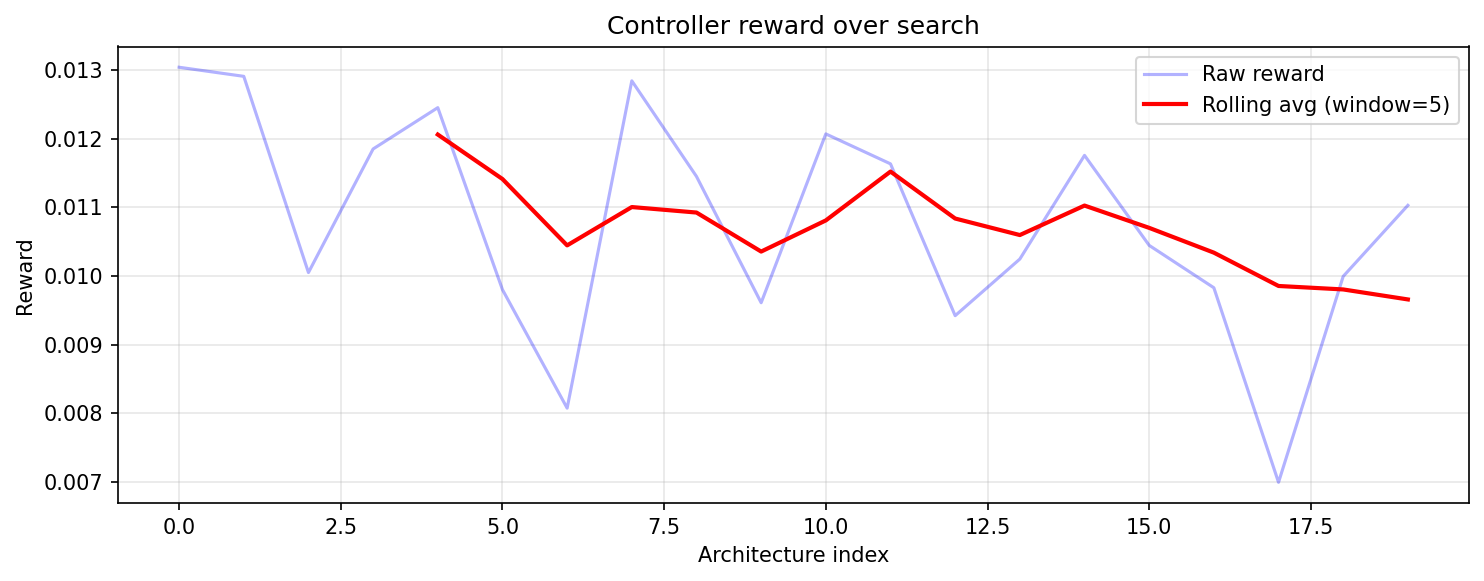

In [13]:
from IPython.display import Image, display # Display in notebook
from visualization.plot_search_progress import (
    plot_search_progress,
    plot_reward_over_time
)

# Reward curve over time
plot_reward_over_time(
    cifar_rewards_history,
    output_path="./results/cifar10/reward_over_time.png",
    window=min(5, len(cifar_rewards_history) // 2)
)

# NAS vs Random comparison (Figure 6)
if len(cifar_rewards_history) >= 5 and len(random_rewards_cifar) >= 5:
    plot_search_progress(
        nas_rewards=cifar_rewards_history,
        random_rewards=random_rewards_cifar,
        output_path="./results/cifar10/nas_vs_random.png",
        k_values=(1, 5, min(15, len(cifar_rewards_history))),
        checkpoint_every=max(1, len(cifar_rewards_history) // 5),
        task="cifar10"
    )

# Display in notebook
print()
print("Reward over time")
display(Image("./results/cifar10/reward_over_time.png"))

# Visualization of the best CIFAR-10 architecture (Figure 7)

CNN architecture plot saved to ./results/cifar10/best_architecture.png
=== Meilleure architecture CNN ===


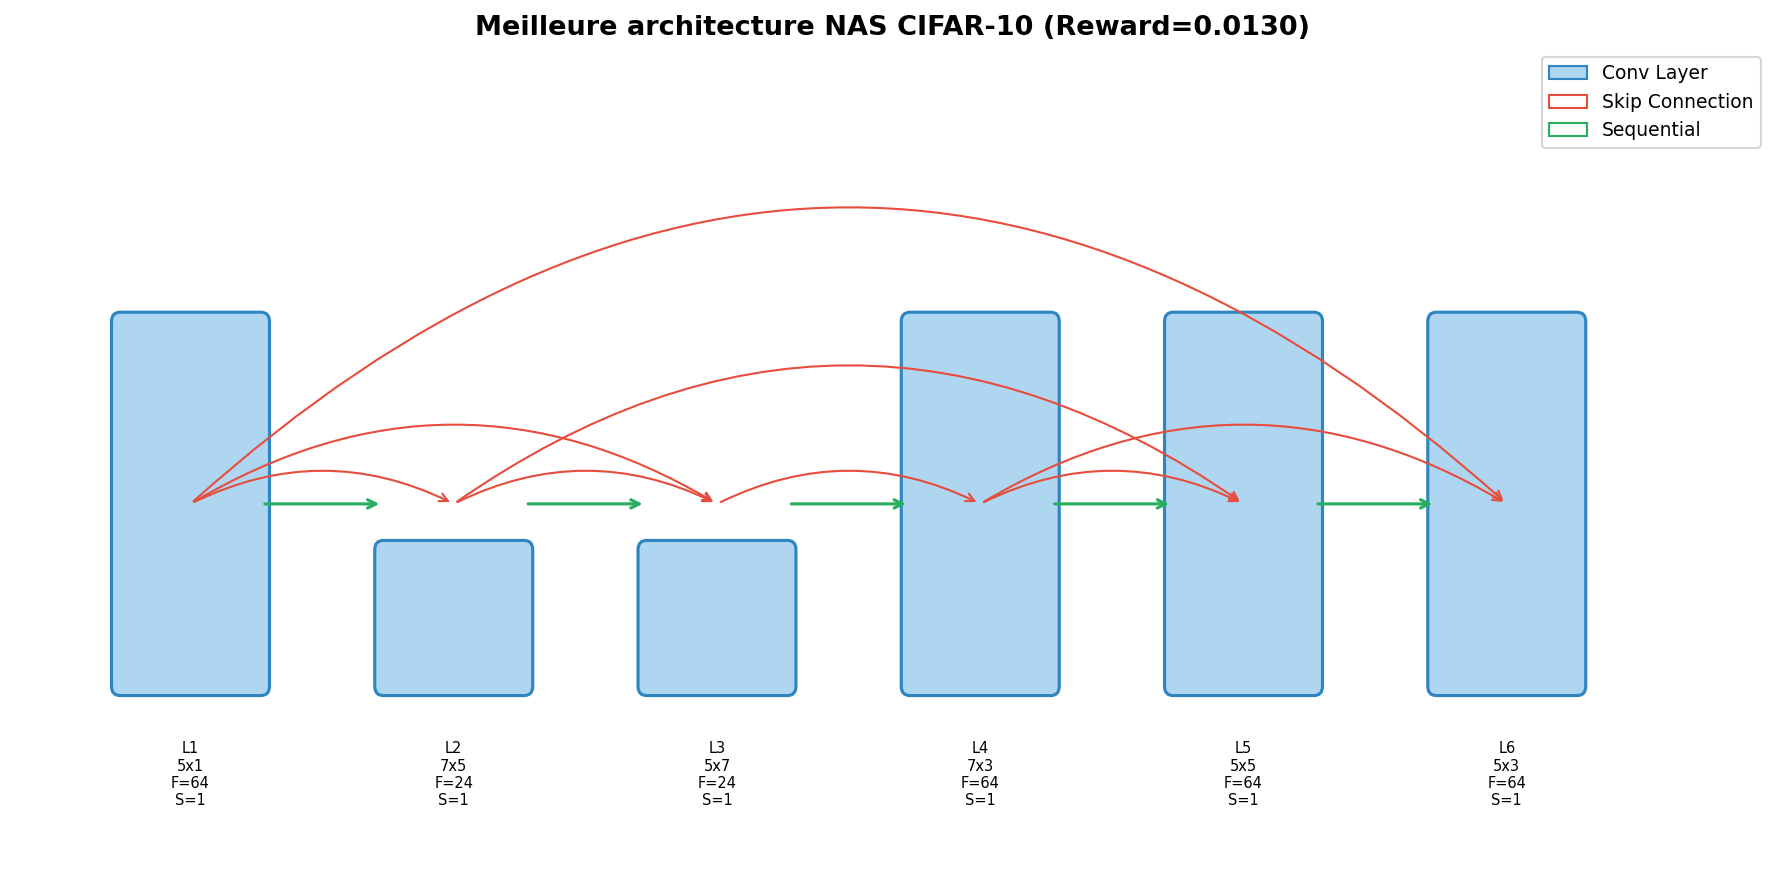

In [14]:
from visualization.plot_architecture import plot_cnn_architecture

plot_cnn_architecture(
    architecture=best_arch_cifar,
    output_path="./results/cifar10/best_architecture.png",
    title=f"Best NAS CIFAR-10 Architecture (Reward={best_reward_cifar:.4f})"
)

print("=== Best CNN Architecture ===")
display(Image("./results/cifar10/best_architecture.png"))

# Final evaluation of the best CIFAR-10 architecture

In [15]:
from evaluation.evaluate_cifar10 import (
    evaluate_final_cifar10,
    count_parameters,
    measure_inference_speed,
    generate_results_table,
    save_evaluation_results
)
from training.train_cifar10 import train_child_cifar10

print("ÉVALUATION FINALE — MEILLEURE ARCHITECTURE CIFAR-10")
print("-" * 60)

# Entraînement final (epochs réduits pour démo)
final_model_cifar = build_child_cnn(best_arch_cifar, num_classes=10)

final_config = dict(CIFAR10_CONFIG)
final_config["child_epochs"] = 10  # 50+ epochs dans le papier, jusqu'à convergence

print(f"Entraînement final ({final_config['child_epochs']} epochs)...")
final_reward, final_val_accs = train_child_cifar10(
    final_model_cifar,
    train_loader_cifar,
    val_loader_cifar,
    final_config,
    device=device
)

# Évaluation sur le test set
test_acc, test_error, test_error_pct = evaluate_final_cifar10(
    final_model_cifar, test_loader_cifar, device=device
)

# Paramètres
num_params = count_parameters(final_model_cifar)

# Vitesse d'inférence
inference_ms = measure_inference_speed(
    final_model_cifar,
    input_shape=(1, 3, 32, 32),
    num_runs=50,
    device=device
)

print()
print("RÉSULTATS FINAUX CIFAR-10")
print("-" * 60)
print(f"  Test Accuracy     : {test_acc * 100:.2f}%")
print(f"  Test Error Rate   : {test_error_pct:.2f}%")
print(f"  Papier (NAS v3)   : 3.65%")
print(f"  Paramètres        : {num_params:,} ({num_params/1e6:.1f}M)")
print(f"  Inférence         : {inference_ms:.2f} ms/image")

# Sauvegarde résultats évaluation
eval_results = {
    "test_accuracy": test_acc,
    "test_error": test_error,
    "test_error_pct": test_error_pct,
    "num_params": num_params,
    "num_params_M": num_params / 1e6,
    "inference_ms": inference_ms,
    "paper_result_pct": 3.65
}
save_evaluation_results(eval_results, "./results/cifar10/final_evaluation.json")

# Tableau comparatif (reproduction Table 1 du papier)
baselines_cifar = {
    "Network in Network": {"error": 8.81},
    "All-CNN": {"error": 7.25},
    "DenseNet (L=40, k=12)": {"depth": 40, "params": "1.0M", "error": 5.24},
    "DenseNet (L=100, k=24)": {"depth": 100, "params": "27.2M", "error": 3.74},
    "DenseNet-BC (L=100, k=40)": {"depth": 100, "params": "25.6M", "error": 3.46},
}
nas_results_table = {
    "NAS v1 (no stride/pooling) [paper]": {"depth": 15, "params": "4.2M", "error": 5.50},
    "NAS v3 max pooling + filters [paper]": {"depth": 39, "params": "37.4M", "error": 3.65},
    f"NAS (réplication, démo)": {"error": round(test_error_pct, 2)},
}
table_str = generate_results_table(nas_results_table, baselines_cifar)
print()
print(table_str)

ÉVALUATION FINALE — MEILLEURE ARCHITECTURE CIFAR-10
Entraînement final (10 epochs)...
Epoch [10/10] Train Loss: 2.0352 Val Acc: 0.2438
CIFAR-10 Test Accuracy: 12.34%
CIFAR-10 Test Error:    87.66%
Model parameters: 812,586 (0.8M)
Inference time: 0.757 ± 0.041 ms (over 50 runs)

RÉSULTATS FINAUX CIFAR-10
  Test Accuracy     : 12.34%
  Test Error Rate   : 87.66%
  Papier (NAS v3)   : 3.65%
  Paramètres        : 812,586 (0.8M)
  Inférence         : 0.76 ms/image
Evaluation results saved to ./results/cifar10/final_evaluation.json

Model                                               Depth   Params   Error%
Network in Network                                      -        -     8.81
All-CNN                                                 -        -     7.25
DenseNet (L=40, k=12)                                  40     1.0M     5.24
DenseNet (L=100, k=24)                                100    27.2M     3.74
DenseNet-BC (L=100, k=40)                             100    25.6M     3.46
-----------

# Penn Treebank

---
## 2. Penn Treebank — Search for Recurrent Cells

### Pipeline :
1. Download and tokenize the PTB dataset (Mikolov preprocessing)
2. Initialize the RNN controller to generate cells (base_number=8)
3. NAS search loop with REINFORCE
4. Final evaluation: word-level perplexity and character-level BPC
5. Comparison NAS vs Random Search

# PTB data loading

In [16]:
from utils.data_loader import get_ptb_data, get_ptb_char_data

print("Loading Penn Treebank (word-level)")
print("  Vocabulary: 10,000 words (Mikolov et al. 2010 preprocessing)")
print("  Splits: train / valid / test")
print()

train_data_ptb, val_data_ptb, test_data_ptb, vocab_size_ptb, word2idx_ptb = \
    get_ptb_data(
        data_dir="./data/ptb",
        batch_size=20,
        eval_batch_size=20
    )

print(f"\nVocabulary     : {vocab_size_ptb} words")
print(f"Train shape    : {train_data_ptb.shape}")
print(f"Val shape      : {val_data_ptb.shape}")
print(f"Test shape     : {test_data_ptb.shape}")

# Check: some tokens
sample_sentence = train_data_ptb[0, :10].tolist()
idx2word = {v: k for k, v in word2idx_ptb.items()}
sample_words = [idx2word.get(t, "<unk>") for t in sample_sentence]
print(f"\nExample (train[0, :10]) : {sample_words}")

Chargement Penn Treebank (word-level)...
  Vocabulaire : 10 000 mots (preprocessing Mikolov et al. 2010)
  Splits : train / valid / test

PTB train already exists at ./data/ptb/ptb.train.txt
PTB valid already exists at ./data/ptb/ptb.valid.txt
PTB test already exists at ./data/ptb/ptb.test.txt
Vocabulary size: 10000
PTB Train: torch.Size([20, 46479]) | Val: torch.Size([20, 3688]) | Test: torch.Size([20, 4121])

Vocabulaire     : 10000 mots
Train shape     : torch.Size([20, 46479])
Val shape       : torch.Size([20, 3688])
Test shape      : torch.Size([20, 4121])

Exemple (train[0, :10]) : ['aer', 'banknote', 'berlitz', 'calloway', 'centrust', 'cluett', 'fromstein', 'gitano', 'guterman', 'hydro-quebec']


# PTB character-level data loading

In [17]:
print("Loading Penn Treebank (character-level)")
print()

train_data_char, val_data_char, test_data_char, vocab_size_char, char2idx = \
    get_ptb_char_data(
        data_dir="./data/ptb",
        batch_size=32
    )

print(f"\nCharacter vocabulary : {vocab_size_char} characters")
print(f"Train shape          : {train_data_char.shape}")
print(f"Val shape            : {val_data_char.shape}")
print(f"Test shape           : {test_data_char.shape}")

idx2char = {v: k for k, v in char2idx.items()}
sample_chars = [idx2char.get(t.item(), "?") for t in train_data_char[0, :30]]
print(f"\nCharacter example (train[0, :30]) : {''.join(sample_chars)}")

Chargement Penn Treebank (character-level)...

PTB train already exists at ./data/ptb/ptb.train.txt
PTB valid already exists at ./data/ptb/ptb.valid.txt
PTB test already exists at ./data/ptb/ptb.test.txt
PTB Char vocab size: 50
Train: torch.Size([32, 159425]) | Val: torch.Size([32, 12493]) | Test: torch.Size([32, 14060])

Vocabulaire char : 50 caractères
Train shape      : torch.Size([32, 159425])
Val shape        : torch.Size([32, 12493])
Test shape       : torch.Size([32, 14060])

Exemple char (train[0, :30]) :  aer banknote berlitz calloway


# PTB controller initialization

In [18]:
from controller.controller_rnn import ControllerRNN
from controller.reinforce import REINFORCETrainer

# Controller for PTB (generates RNN cells)
controller_ptb = ControllerRNN(PTB_CONFIG, task="ptb").to(device)

print("PTB RNN controller initialized:")
print(f"  Base number        : {PTB_CONFIG['base_number']}")
print(f"  Search space size  : ~6e16 architectures")
print(f"  Combinations       : {PTB_CONFIG['combination_methods']}")
print(f"  Activations        : {PTB_CONFIG['activation_functions']}")
print(f"  Hidden units       : {PTB_CONFIG['controller_hidden_units']}")
print(f"  Learning rate      : {PTB_CONFIG['controller_lr']}")
print()
print(f"PTB controller parameters : {count_parameters_M(controller_ptb):.3f} M")

reinforce_ptb = REINFORCETrainer(controller_ptb, PTB_CONFIG)
print("PTB REINFORCE trainer initialized.")

Contrôleur RNN PTB initialisé :
  Base number        : 8
  Taille espace      : ~6e16 architectures
  Combinaisons       : ['add', 'elem_mult']
  Activations        : ['identity', 'tanh', 'sigmoid', 'relu']
  Hidden units       : 35
  Learning rate      : 0.0005

Paramètres contrôleur PTB : 0.021 M
Trainer REINFORCE PTB initialisé.


# PTB sampling test (sanity check)

In [19]:
print("Sanity Check — PTB Cell Sampling")
print()

controller_ptb.eval()
with torch.no_grad():
    sample_cell, sample_log_probs_ptb = controller_ptb.forward_ptb(
        base_number=PTB_CONFIG["base_number"]
    )

print("Sampled cell:")
print(f"  combination_methods   : {sample_cell['combination_methods']}")
print(f"  activation_functions  : {sample_cell['activation_functions']}")
print(f"  cell_ct_index         : {sample_cell['cell_ct_index']}")
print(f"  cell_ct_new_index     : {sample_cell['cell_ct_new_index']}")
print(f"\nNumber of log_prob decisions : {len(sample_log_probs_ptb)}")
print("PTB Controller works correctly.")

=== Sanity Check — Sampling cellule PTB ===

Cellule samplée :
  combination_methods   : ['elem_mult', 'elem_mult', 'add', 'elem_mult', 'add', 'elem_mult', 'elem_mult', 'elem_mult', 'add', 'add', 'add', 'elem_mult', 'add', 'add', 'elem_mult']
  activation_functions  : ['relu', 'sigmoid', 'tanh', 'identity', 'identity', 'relu', 'tanh', 'identity', 'sigmoid', 'identity', 'sigmoid', 'identity', 'sigmoid', 'tanh', 'tanh']
  cell_ct_index         : 6
  cell_ct_new_index     : 5

Nombre de décisions log_prob : 32
Contrôleur PTB fonctionne correctement.


# Define PTB child training function

In [20]:
from child_networks.rnn_cell_builder import NASRNNModel
from training.train_ptb import train_child_ptb
from utils.metrics import ptb_reward
import math

PTB_HIDDEN_SIZE = 200
PTB_EMBED_SIZE  = 200

def build_ptb_model(cell_architecture, config=None):
    cfg = config if config else PTB_CONFIG
    dropout = cfg.get("child_dropout", 0.65)
    return NASRNNModel(
        cell_architecture=cell_architecture,
        vocab_size=vocab_size_ptb,
        embed_size=PTB_EMBED_SIZE,
        hidden_size=PTB_HIDDEN_SIZE,
        num_layers=2,
        dropout_rate=dropout,
        embedding_dropout_rate=0.1
    )


def train_child_ptb_wrapper(cell_architecture, verbose=False):
    try:
        model = build_ptb_model(cell_architecture)

        demo_config = dict(PTB_CONFIG)
        demo_config["child_epochs"] = 3
        demo_config["batch_size_ptb"] = 20
        demo_config["bptt_length"] = 35

        reward, val_ppls = train_child_ptb(
            model,
            train_data_ptb,
            val_data_ptb,
            demo_config,
            device=device
        )

        # Guard against NaN, inf, or unreasonably high perplexity
        valid_ppls = [p for p in val_ppls if math.isfinite(p) and p < 10000]
        if len(valid_ppls) == 0:
            if verbose:
                print(f"  All perplexities invalid: {val_ppls}")
            return -1000.0

        best_ppl = min(valid_ppls)
        reward = -best_ppl

        if verbose:
            print(f"  Val PPL (last): {[f'{p:.1f}' for p in val_ppls[-3:]]}")
            print(f"  Reward        : {reward:.4f}")

        return float(reward)

    except Exception as e:
        if verbose:
            print(f"  Error: {e}")
        return -1000.0


print("PTB child training function defined.")
print(f"  Vocab size    : {vocab_size_ptb}")
print(f"  Hidden size   : {PTB_HIDDEN_SIZE}")
print(f"  Embed size    : {PTB_EMBED_SIZE}")
print(f"  Epochs (demo) : 3  [paper: 35]")
print(f"  Reward        : -val_perplexity (clipped to -1000 if invalid)")

PTB child training function defined.
  Vocab size    : 10000
  Hidden size   : 200
  Embed size    : 200
  Epochs (demo) : 3  [paper: 35]
  Reward        : -val_perplexity (clipped to -1000 if invalid)


# Test a manual cell (sanity check PTB)

In [21]:
print("Sanity Check: manual cell (LSTM-like)")
print()

# LSTM-like cell for verification
lstm_like_arch = {
    "combination_methods": ["add", "elem_mult"] * 7 + ["add"],
    "activation_functions": ["tanh", "sigmoid", "tanh", "sigmoid",
                              "tanh", "sigmoid", "tanh", "sigmoid",
                              "tanh", "sigmoid", "tanh", "sigmoid",
                              "tanh", "sigmoid", "tanh"],
    "cell_ct_index": 0,
    "cell_ct_new_index": 1
}

test_model_ptb = build_ptb_model(lstm_like_arch)
print(f"PTB test model parameters : {count_parameters_M(test_model_ptb):.3f} M")

# Forward pass
dummy_input = torch.randint(0, vocab_size_ptb, (35, 20))  # [seq_len, batch]
hidden = test_model_ptb.init_hidden(20)
with torch.no_grad():
    logits, new_hidden = test_model_ptb(dummy_input, hidden)
print(f"Logits shape : {logits.shape}  (expected: [{35*20}, {vocab_size_ptb}])")

# Quick reward
print()
print("Test PTB child training")
reward_test = train_child_ptb_wrapper(lstm_like_arch, verbose=True)
print(f"\nSanity check PTB OK. Reward : {reward_test:.4f}")

=== Sanity Check : cellule manuelle (LSTM-like) ===

Paramètres modèle PTB test : 5.293 M
Logits shape : torch.Size([700, 10000])  (attendu : [700, 10000])

Test entraînement child PTB...
  Val PPL (last): ['701.3', '693.3', '691.5']
  Reward        : -691.4638

Sanity check PTB OK. Reward : -691.4638


# PTB NAS search loop

In [22]:
import torch
import numpy as np
import os

os.makedirs("./results/ptb", exist_ok=True)

DEMO_ARCHITECTURES_PTB = 15

print("STARTING NAS — PENN TREEBANK")
print("-" * 60)
print(f"Cells to evaluate (demo)  : {DEMO_ARCHITECTURES_PTB}")
print(f"Cells in paper            : ~15 000")
print(f"Search space              : ~6e16 architectures")
print()

ptb_rewards_history = []
ptb_baselines_history = []
ptb_losses_history = []
ptb_cells_history = []

# Reinitialize controller and optimizer to avoid NaN state from previous run
from controller.controller_rnn import ControllerRNN
from controller.reinforce import REINFORCETrainer

controller_ptb = ControllerRNN(PTB_CONFIG, task="ptb").to(device)
reinforce_ptb  = REINFORCETrainer(controller_ptb, PTB_CONFIG)

controller_ptb.train()

for i in range(DEMO_ARCHITECTURES_PTB):
    # Sample a cell architecture
    cell_arch, log_probs = controller_ptb.forward_ptb(
        base_number=PTB_CONFIG["base_number"]
    )

    # Train child and get reward
    reward = train_child_ptb_wrapper(cell_arch)

    # Skip REINFORCE update if reward is invalid
    if not math.isfinite(reward):
        print(f"  [{i+1:>3}/{DEMO_ARCHITECTURES_PTB}] Skipping invalid reward: {reward}")
        continue

    # REINFORCE update
    loss = reinforce_ptb.step([log_probs], [reward])

    # Skip logging if loss is NaN
    if not math.isfinite(loss):
        print(f"  [{i+1:>3}/{DEMO_ARCHITECTURES_PTB}] Skipping NaN loss")
        continue

    # Logging
    ptb_rewards_history.append(reward)
    ptb_baselines_history.append(
        reinforce_ptb.baseline if reinforce_ptb.baseline is not None else 0.0
    )
    ptb_losses_history.append(loss)
    ptb_cells_history.append({
        "cell": _make_serializable(cell_arch),
        "reward": float(reward)
    })

    if (i + 1) % 3 == 0 or (i + 1) == DEMO_ARCHITECTURES_PTB:
        print(
            f"  [{i+1:>3}/{DEMO_ARCHITECTURES_PTB}] "
            f"Reward: {reward:.4f} | "
            f"Baseline: {reinforce_ptb.baseline:.4f} | "
            f"Loss: {loss:.4f}"
        )

print()
if len(ptb_rewards_history) > 0:
    print("NAS PTB search complete.")
    print(f"Best reward  : {max(ptb_rewards_history):.4f}  (PPL ~ {-max(ptb_rewards_history):.1f})")
    print(f"Mean reward  : {np.mean(ptb_rewards_history):.4f}")
else:
    print("No valid architectures found. Consider increasing child_epochs or reducing hidden size.")

STARTING NAS — PENN TREEBANK
Cells to evaluate (demo)  : 15
Cells in paper            : ~15 000
Search space              : ~6e16 architectures

  [  3/15] Reward: -1000.0000 | Baseline: -764.9528 | Loss: -8294.5205
  [  6/15] Reward: -1000.0000 | Baseline: -768.0889 | Loss: -8193.4492
  [  9/15] Reward: -712.7605 | Baseline: -768.1885 | Loss: 1964.5049
  [ 12/15] Reward: -702.9721 | Baseline: -768.0364 | Loss: 2298.0317
  [ 15/15] Reward: -702.0082 | Baseline: -767.8477 | Loss: 2338.6494

NAS PTB search complete.
Best reward  : -691.5280  (PPL ~ 691.5)
Mean reward  : -991.5434


# Identify and save the best PTB cell

In [23]:
# The best cell = the one with the highest reward (= lowest perplexity)
best_idx_ptb = int(np.argmax(ptb_rewards_history))
best_cell_ptb = ptb_cells_history[best_idx_ptb]["cell"]
best_reward_ptb = ptb_rewards_history[best_idx_ptb]

print("BEST PTB CELL")
print("-" * 60)
print(f"Index       : {best_idx_ptb}")
print(f"Reward      : {best_reward_ptb:.4f}")
print(f"Perplexity ~: {-best_reward_ptb:.2f}")
print()
print("Cell:")
for k, v in best_cell_ptb.items():
    print(f"  {k} : {v}")

# Save results
with open("./results/ptb/best_cell.json", "w") as f:
    json.dump({
        "cell": best_cell_ptb,
        "reward": float(best_reward_ptb)
    }, f, indent=2)

with open("./results/ptb/all_cells.json", "w") as f:
    json.dump(ptb_cells_history, f, indent=2)

with open("./results/ptb/search_log.csv", "w") as f:
    f.write("index,reward,baseline,loss\n")
    for i in range(len(ptb_rewards_history)):
        f.write(
            f"{i},"
            f"{ptb_rewards_history[i]:.6f},"
            f"{ptb_baselines_history[i]:.6f},"
            f"{ptb_losses_history[i]:.6f}\n"
        )

print()
print("Results saved in ./results/ptb/")

MEILLEURE CELLULE PTB
Index         : 7
Reward        : -691.5280
Perplexité ~  : 691.53

Cellule :
  combination_methods : ['add', 'add', 'elem_mult', 'add', 'add', 'elem_mult', 'elem_mult', 'add', 'add', 'add', 'add', 'elem_mult', 'elem_mult', 'add', 'elem_mult']
  activation_functions : ['identity', 'tanh', 'relu', 'sigmoid', 'tanh', 'tanh', 'tanh', 'identity', 'tanh', 'tanh', 'tanh', 'sigmoid', 'identity', 'tanh', 'tanh']
  cell_ct_index : 4
  cell_ct_new_index : 1

Résultats sauvegardés dans ./results/ptb/


# Random Search baseline PTB

In [24]:
from search.random_search import RandomSearch

print("=" * 60)
print("RANDOM SEARCH BASELINE — PTB")
print("=" * 60)

random_search_ptb = RandomSearch(PTB_CONFIG, task="ptb")
random_rewards_ptb = []

for i in range(DEMO_ARCHITECTURES_PTB):
    rand_cell = random_search_ptb.sample_ptb_cell()
    reward = train_child_ptb_wrapper(rand_cell)
    random_rewards_ptb.append(reward)
    random_search_ptb.all_results.append({
        "cell": _make_serializable(rand_cell),
        "reward": float(reward)
    })

    if (i + 1) % 3 == 0 or (i + 1) == DEMO_ARCHITECTURES_PTB:
        print(
            f"  [{i+1:>3}/{DEMO_ARCHITECTURES_PTB}] "
            f"Reward: {reward:.4f} | "
            f"Best: {max(random_rewards_ptb):.4f}"
        )

print()
print(f"Random Search PTB completed.")
print(f"Best random reward : {max(random_rewards_ptb):.4f}  "
      f"(PPL ~{-max(random_rewards_ptb):.1f})")
print(f"Best NAS reward    : {max(ptb_rewards_history):.4f}  "
      f"(PPL ~{-max(ptb_rewards_history):.1f})")
print(f"NAS advantage      : {max(ptb_rewards_history) - max(random_rewards_ptb):.4f}")

random_search_ptb.save_results("./results/ptb")

RANDOM SEARCH BASELINE — PTB
  [  3/15] Reward: -694.8109 | Best: -693.6473
  [  6/15] Reward: -698.3230 | Best: -693.6473
  [  9/15] Reward: -1000.0000 | Best: -693.6473
  [ 12/15] Reward: -699.8321 | Best: -690.5151
  [ 15/15] Reward: -695.0130 | Best: -690.5151

Random Search PTB terminé.
Meilleur reward random : -690.5151  (PPL ~690.5)
Meilleur reward NAS    : -691.5280  (PPL ~691.5)
Avantage NAS           : -1.0129
Random search results saved to ./results/ptb/random_search_results.json


# NAS vs Random curves PTB (Figure 6 reproduction)

Reward plot saved to ./results/ptb/reward_over_time.png
Search progress plot saved to ./results/ptb/nas_vs_random_ptb.png
=== Reward PTB over time ===


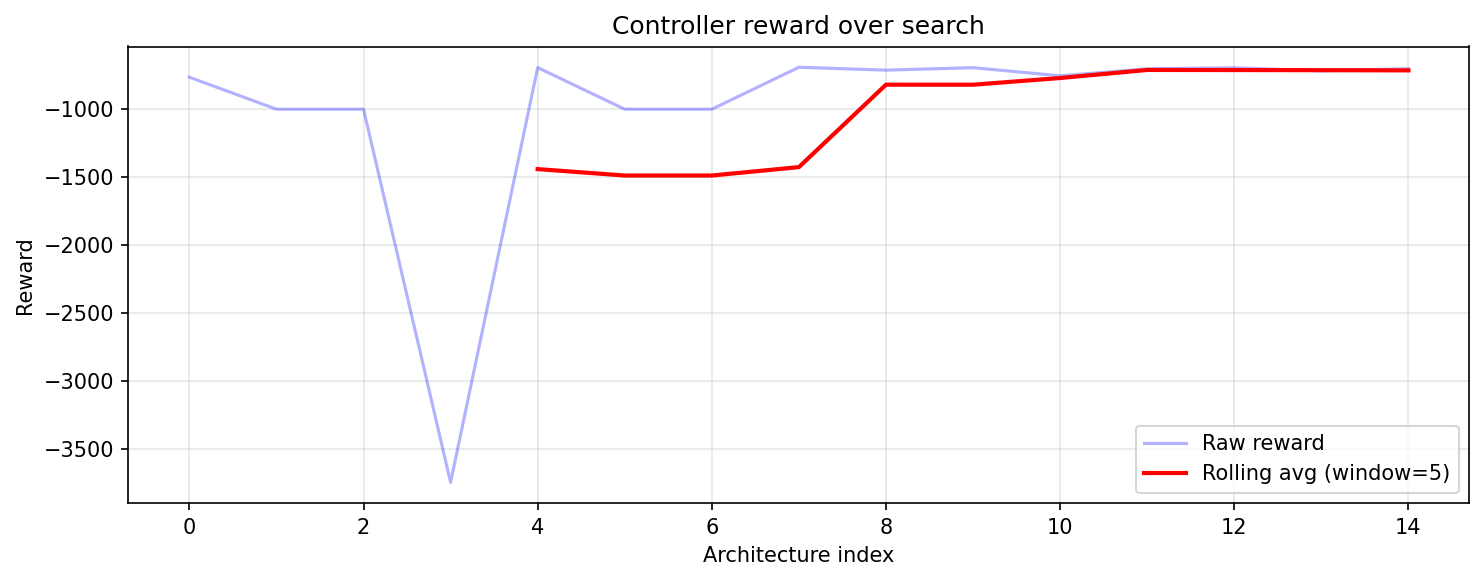

In [25]:
# Reproduction of Figure 6 — PTB
plot_reward_over_time(
    ptb_rewards_history,
    output_path="./results/ptb/reward_over_time.png",
    window=min(5, len(ptb_rewards_history) // 2)
)

if len(ptb_rewards_history) >= 5:
    plot_search_progress(
        nas_rewards=ptb_rewards_history,
        random_rewards=random_rewards_ptb,
        output_path="./results/ptb/nas_vs_random_ptb.png",
        k_values=(1, min(5, DEMO_ARCHITECTURES_PTB),
                  min(15, DEMO_ARCHITECTURES_PTB)),
        checkpoint_every=max(1, DEMO_ARCHITECTURES_PTB // 5),
        task="ptb"
    )

print("PTB reward over time")
display(Image("./results/ptb/reward_over_time.png"))

# Visualization of the best PTB cell (Figure 8)

RNN cell plot saved to ./results/ptb/best_cell.png
=== Meilleure cellule RNN découverte ===


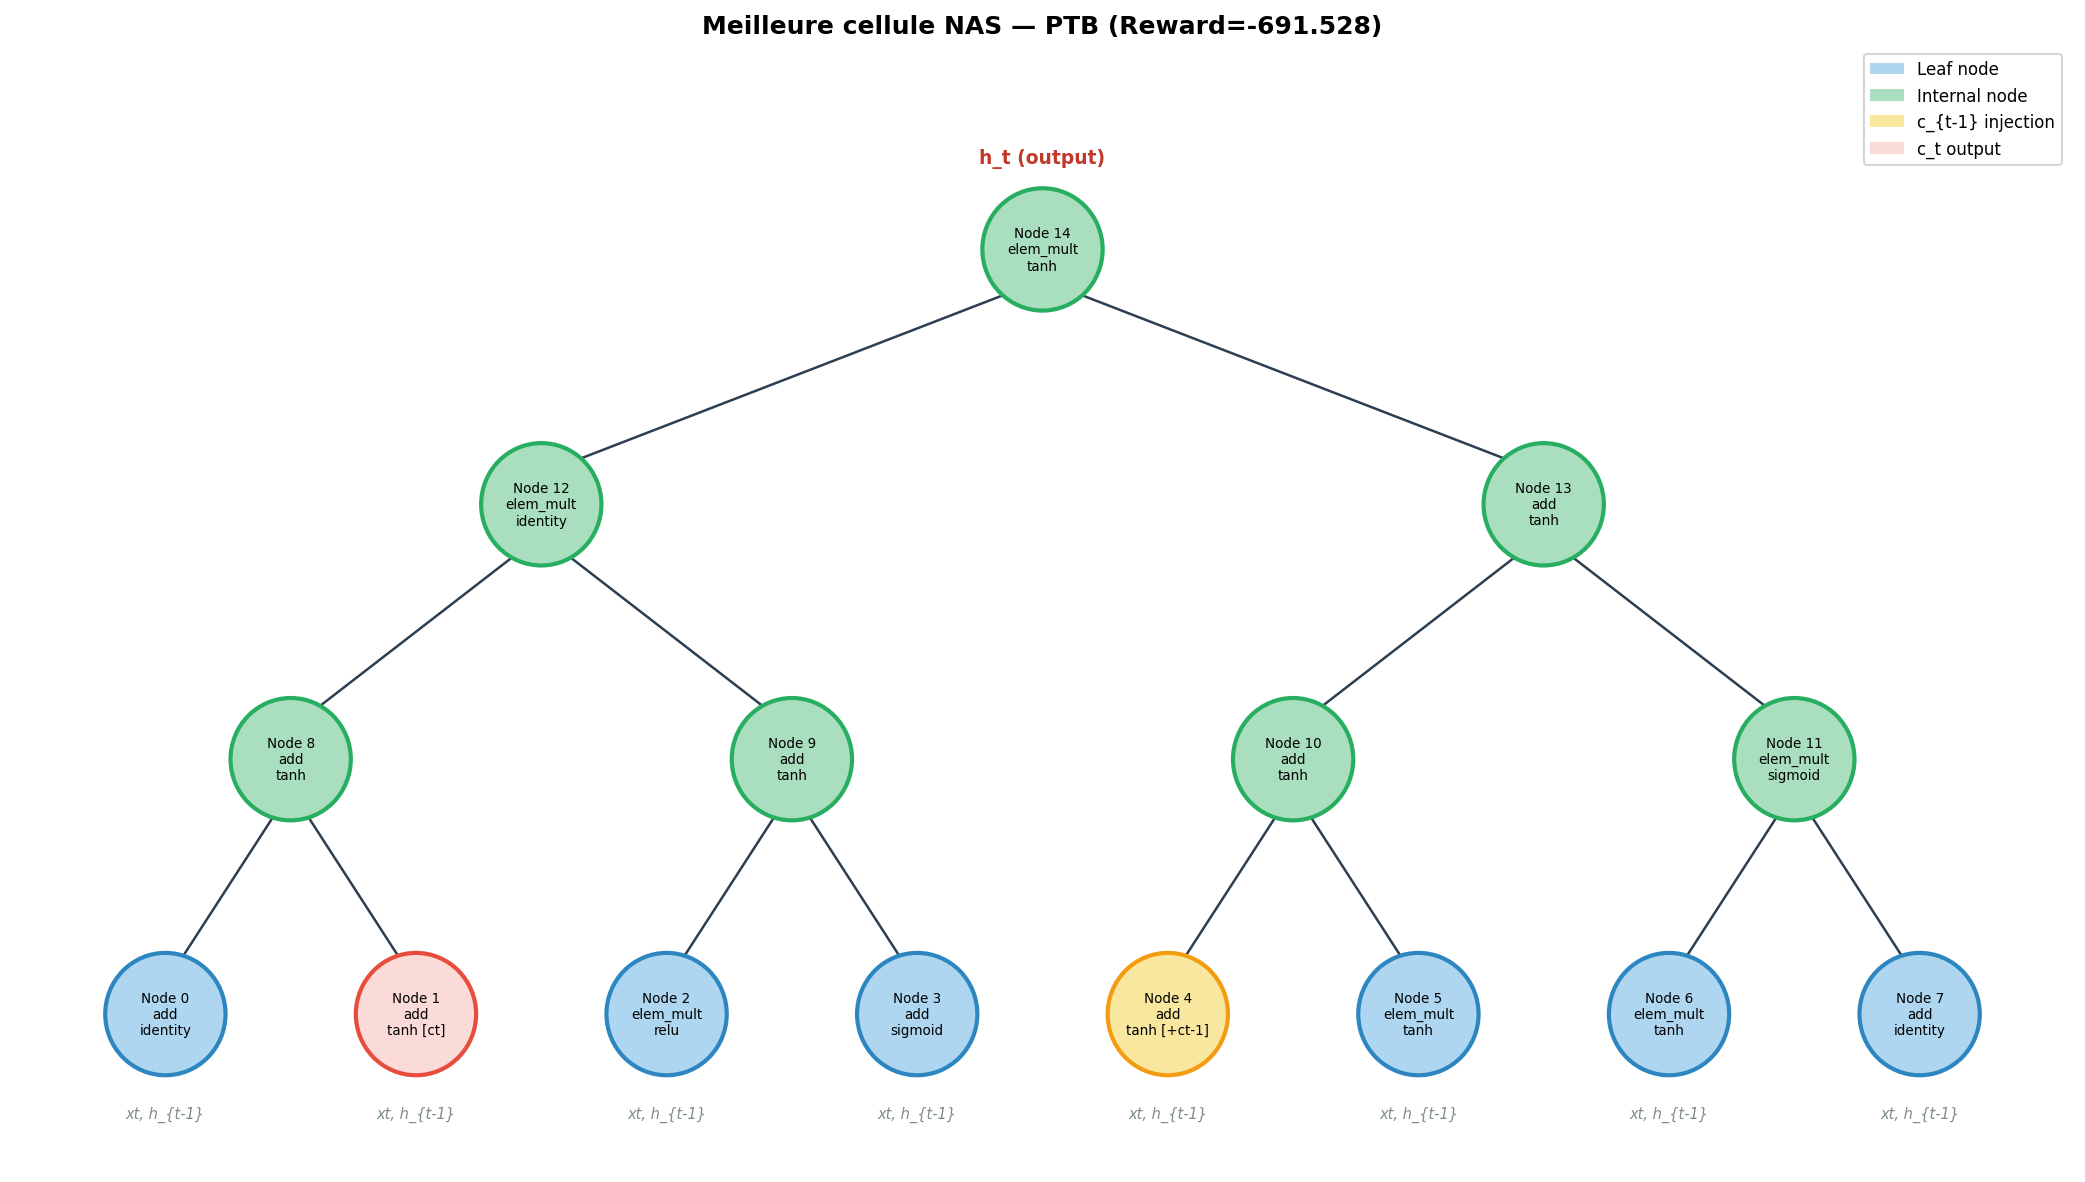

In [26]:
from visualization.plot_rnn_cell import plot_rnn_cell

plot_rnn_cell(
    cell_architecture=best_cell_ptb,
    output_path="./results/ptb/best_cell.png",
    title=f"Best NAS Cell — PTB (Reward={best_reward_ptb:.3f})"
)

print("Best discovered RNN cell")
display(Image("./results/ptb/best_cell.png"))

# Final word-level evaluation on PTB

In [27]:
from evaluation.evaluate_ptb import (
    evaluate_final_ptb,
    evaluate_character_ptb,
    generate_perplexity_table,
    save_ptb_results
)
from training.train_ptb import grid_search_ptb

print("FINAL EVALUATION — PTB WORD-LEVEL")
print("-" * 60)

# Final training of the best model
final_model_ptb = build_ptb_model(best_cell_ptb)

final_config_ptb = dict(PTB_CONFIG)
final_config_ptb["child_epochs"] = 5    # 35 in the paper
final_config_ptb["batch_size_ptb"] = 20
final_config_ptb["bptt_length"] = 35
final_config_ptb["child_lr_ptb"] = 1.0

print(f"Final training ({final_config_ptb['child_epochs']} epochs)")
from training.train_ptb import train_child_ptb, evaluate_ptb
import torch.nn as nn

_, final_val_ppls = train_child_ptb(
    final_model_ptb,
    train_data_ptb,
    val_data_ptb,
    final_config_ptb,
    device=device
)

# Test perplexity
test_ppl = evaluate_final_ptb(
    final_model_ptb,
    test_data_ptb,
    bptt=35,
    batch_size=20,
    device=device
)

print()
print("FINAL PTB WORD-LEVEL RESULTS")
print("-" * 60)
print(f"  Test Perplexity (replication)  : {test_ppl:.2f}")
print(f"  Paper (NAS base 8, 32M)       : 67.9")
print(f"  Paper (NAS + shared emb, 25M) : 64.0")
print(f"  Paper (NAS + shared emb, 54M) : 62.4")

# Comparative table (Table 2 of the paper)
baselines_ptb = {
    "LSTM medium (Zaremba 2014)":        {"params": "20M",  "perplexity": 82.7},
    "LSTM large (Zaremba 2014)":         {"params": "66M",  "perplexity": 78.4},
    "Var LSTM large (Gal 2015)":         {"params": "66M",  "perplexity": 75.2},
    "Pointer Sentinel-LSTM (Merity)":    {"params": "21M",  "perplexity": 70.9},
    "Var RHN shared emb (Zilly 2016)":   {"params": "24M",  "perplexity": 66.0},
}
nas_results_ptb = {
    "NAS base 8 [paper]":                {"params": "32M",  "perplexity": 67.9},
    "NAS base 8 + shared emb [paper]":   {"params": "25M",  "perplexity": 64.0},
    "NAS base 8 + shared emb 54M [pap]": {"params": "54M",  "perplexity": 62.4},
    "NAS replication (demo)":            {"perplexity": round(test_ppl, 1)},
}

table_ptb = generate_perplexity_table(nas_results_ptb, baselines_ptb)
print()
print(table_ptb)

# Save results
ptb_eval_results = {
    "word_level_test_ppl": test_ppl,
    "paper_result_32M": 67.9,
    "paper_result_62_4": 62.4,
    "final_val_ppls": final_val_ppls
}
save_ptb_results(ptb_eval_results, "./results/ptb/final_evaluation.json")

ÉVALUATION FINALE — PTB WORD-LEVEL
Entraînement final (5 epochs)...
Epoch [5/5] Train PPL: 705.69 Val PPL: 689.07
PTB Test Perplexity: 645.99

RÉSULTATS FINAUX PTB WORD-LEVEL
  Test Perplexity (réplication)  : 645.99
  Papier (NAS base 8, 32M)       : 67.9
  Papier (NAS + shared emb, 25M) : 64.0
  Papier (NAS + shared emb, 54M) : 62.4

Model                                           Params      PPL
LSTM medium (Zaremba 2014)                         20M     82.7
LSTM large (Zaremba 2014)                          66M     78.4
Var LSTM large (Gal 2015)                          66M     75.2
Pointer Sentinel-LSTM (Merity)                     21M     70.9
Var RHN shared emb (Zilly 2016)                    24M     66.0
-----------------------------------------------------------------
NAS base 8 [paper]                                 32M     67.9
NAS base 8 + shared emb [paper]                    25M     64.0
NAS base 8 + shared emb 54M [pap]                  54M     62.4
NAS réplication (dém

# PTB character-level evaluation (transfer)

In [28]:
from child_networks.rnn_cell_builder import NASRNNModel

print("EVALUATION — PTB CHARACTER-LEVEL (Transfer Learning)")
print("-" * 60)
print("The cell discovered in word-level is reused")
print("for character-level modeling (Section 4.2 of the paper).")
print()

# Character-level model using the discovered NAS cell
# Paper large configuration: 16.28M params, 800 hidden, ADAM, lr=0.001
char_model = NASRNNModel(
    cell_architecture=best_cell_ptb,
    vocab_size=vocab_size_char,
    embed_size=128,             # paper: 128
    hidden_size=256,            # paper: 800 (reduced for demo)
    num_layers=2,
    dropout_rate=0.2,
    embedding_dropout_rate=0.0
)

print(f"Character-level model : {count_parameters_M(char_model):.2f}M params")
print(f"  (Paper large   : 16.28M params, 800 hidden units)")
print()

# Quick training
import torch.optim as optim

char_model = char_model.to(device)
char_optimizer = optim.Adam(char_model.parameters(), lr=0.001)
char_criterion = nn.CrossEntropyLoss()

print("Quick training (3 epochs for demo, paper: 600K steps)")
for epoch in range(3):
    char_model.train()
    total_loss = 0
    n_batches = 0
    hidden = char_model.init_hidden(32)

    bptt = 100
    for i in range(0, min(train_data_char.size(1) - 1, 500), bptt):
        seq_len = min(bptt, train_data_char.size(1) - 1 - i)
        data = train_data_char[:, i:i+seq_len].to(device)
        targets = train_data_char[:, i+1:i+seq_len+1].to(device).reshape(-1)

        char_optimizer.zero_grad()
        logits, hidden = char_model(data.t(), hidden)
        loss = char_criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(char_model.parameters(), 5.0)
        char_optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    avg_loss = total_loss / max(n_batches, 1)
    import math
    print(f"  Epoch {epoch+1}: loss={avg_loss:.4f}, BPC={avg_loss/math.log(2):.3f}")

# Final character-level evaluation
test_bpc = evaluate_character_ptb(
    char_model, test_data_char,
    bptt=100, batch_size=32, device=device
)

print()
print("CHARACTER-LEVEL RESULTS")
print(f"  BPC replication (demo) : {test_bpc:.3f}")
print(f"  Paper (NAS 6.57M)      : 1.228")
print(f"  Paper (NAS 16.28M)     : 1.214 (state-of-the-art)")
print(f"  LSTM 2-layer baseline   : 1.243")

ÉVALUATION — PTB CHARACTER-LEVEL (Transfer Learning)
La cellule découverte en word-level est réutilisée
pour le character-level modeling (Section 4.2 du papier).

Modèle char-level : 1.86M params
  (Papier large   : 16.28M params, 800 hidden units)

Entraînement rapide (3 epochs pour démo, papier: 600K steps)...
  Epoch 1: loss=3.8627, BPC=5.573
  Epoch 2: loss=3.3737, BPC=4.867
  Epoch 3: loss=3.0771, BPC=4.439
PTB Character-level BPC: 4.388

RÉSULTATS CHARACTER-LEVEL
  BPC réplication (démo) : 4.388
  Papier (NAS 6.57M)     : 1.228
  Papier (NAS 16.28M)    : 1.214 (state-of-the-art)
  LSTM 2-layer baseline  : 1.243


# Section 3 — Control Experiments

3.1 Adding functions to the search space (max, sin)

3.2 NAS vs Random Search comparison (full synthesis)

# Control Experiment 1 — Extended search space (max, sin)

In [29]:
print("CONTROL EXPERIMENT 1: Extended search space (max, sin)")
print("-" * 60)
print("Added 'max' to combinations and 'sin' to activations")
print("to test NAS robustness.")
print()

# Config with extended functions
extended_config = dict(PTB_CONFIG)
extended_config["combination_methods"] = ["add", "elem_mult", "max"]
extended_config["activation_functions"] = ["identity", "tanh", "sigmoid", "relu", "sin"]
extended_config["controller_lr"] = 0.0005

# New controller with extended space
controller_extended = ControllerRNN(extended_config, task="ptb").to(device)
reinforce_extended = REINFORCETrainer(controller_extended, extended_config)

DEMO_EXTENDED = 10  # reduced for demo
extended_rewards = []

controller_extended.train()
for i in range(DEMO_EXTENDED):
    cell_arch_ext, log_probs_ext = controller_extended.forward_ptb(
        base_number=extended_config.get("base_number", 8)
    )
    reward_ext = train_child_ptb_wrapper(cell_arch_ext)
    loss_ext = reinforce_extended.step([log_probs_ext], [reward_ext])
    extended_rewards.append(reward_ext)

    if (i + 1) % 3 == 0 or (i + 1) == DEMO_EXTENDED:
        print(
            f"  [{i+1:>2}/{DEMO_EXTENDED}] "
            f"Reward: {reward_ext:.4f} | "
            f"Loss: {loss_ext:.4f}"
        )

print()
print(f"Standard space  — Best reward : {max(ptb_rewards_history):.4f}")
print(f"Extended space  — Best reward : {max(extended_rewards):.4f}")
print()
print("Conclusion (paper) : comparable performance despite larger search space.")

EXPÉRIENCE CONTRÔLE 1 : Espace étendu (max, sin)
Ajout de 'max' aux combinaisons et 'sin' aux activations
pour vérifier la robustesse du NAS.

  [ 3/10] Reward: -904.0563 | Loss: -8563.5625
  [ 6/10] Reward: -692.0682 | Loss: 914.8540
  [ 9/10] Reward: -2828.8466 | Loss: -94418.7422
  [10/10] Reward: -730.4111 | Loss: -701.6072

Espace standard  — Meilleur reward : -691.5280
Espace étendu    — Meilleur reward : -692.0682

Conclusion (papier) : performances comparables malgré l'espace plus grand.


# Comparative summary NAS vs Random Search

In [30]:
from utils.metrics import compare_top_k

print("SUMMARY: NAS vs RANDOM SEARCH")
print("-" * 60)
print()

# CIFAR-10
print("--- CIFAR-10 ---")
k_vals = [1, min(5, len(cifar_rewards_history)), min(15, len(cifar_rewards_history))]
k_vals = sorted(set(k_vals))
comparison_cifar = compare_top_k(cifar_rewards_history, random_rewards_cifar, k_vals)
for k, res in comparison_cifar.items():
    print(
        f"  Top-{k:>2} | NAS: {res['method_a']:.5f} | "
        f"Random: {res['method_b']:.5f} | "
        f"Diff: {res['diff_a_minus_b']:+.5f}"
    )

print()
print("--- PTB ---")
k_vals_ptb = [1, min(5, len(ptb_rewards_history)), min(15, len(ptb_rewards_history))]
k_vals_ptb = sorted(set(k_vals_ptb))
comparison_ptb = compare_top_k(ptb_rewards_history, random_rewards_ptb, k_vals_ptb)
for k, res in comparison_ptb.items():
    print(
        f"  Top-{k:>2} | NAS: {res['method_a']:.4f} | "
        f"Random: {res['method_b']:.4f} | "
        f"Diff: {res['diff_a_minus_b']:+.4f}"
    )

print()
print("Conclusion (paper) : NAS outperforms Random Search")
print("  - best overall architecture (Top-1)")
print("  - better average of top models (Top-5, Top-15)")

SYNTHÈSE : NAS vs RANDOM SEARCH

--- CIFAR-10 ---
  Top- 1 | NAS: 0.01304 | Random: 0.01249 | Diff: +0.00056
  Top- 5 | NAS: 0.01267 | Random: 0.01233 | Diff: +0.00033
  Top-15 | NAS: 0.01144 | Random: 0.01158 | Diff: -0.00014

--- PTB ---
  Top- 1 | NAS: -691.5280 | Random: -690.5151 | Diff: -1.0129
  Top- 5 | NAS: -695.5131 | Random: -692.3500 | Diff: -3.1631
  Top-15 | NAS: -991.5434 | Random: -745.3777 | Diff: -246.1657

Conclusion (papier) : NAS surpasse Random Search
  - meilleure architecture globale (Top-1)
  - meilleure moyenne des top modèles (Top-5, Top-15)


# Final comparative plots

In [31]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CIFAR-10
ax = axes[0]
ax.plot(cifar_rewards_history, alpha=0.5, color="blue", label="NAS (CIFAR-10)")
ax.plot(random_rewards_cifar, alpha=0.5, color="red", label="Random (CIFAR-10)")
ax.axhline(
    max(cifar_rewards_history), color="blue",
    linestyle="--", linewidth=1,
    label=f"NAS best={max(cifar_rewards_history):.4f}"
)
ax.axhline(
    max(random_rewards_cifar), color="red",
    linestyle="--", linewidth=1,
    label=f"Random best={max(random_rewards_cifar):.4f}"
)
ax.set_xlabel("Architecture index")
ax.set_ylabel("Reward (val_acc^3)")
ax.set_title("NAS vs Random Search — CIFAR-10")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# PTB
ax = axes[1]
ax.plot(ptb_rewards_history, alpha=0.5, color="blue", label="NAS (PTB)")
ax.plot(random_rewards_ptb, alpha=0.5, color="red", label="Random (PTB)")
ax.axhline(
    max(ptb_rewards_history), color="blue",
    linestyle="--", linewidth=1,
    label=f"NAS best={max(ptb_rewards_history):.3f}"
)
ax.axhline(
    max(random_rewards_ptb), color="red",
    linestyle="--", linewidth=1,
    label=f"Random best={max(random_rewards_ptb):.3f}"
)
ax.set_xlabel("Cell index")
ax.set_ylabel("Reward (-perplexity)")
ax.set_title("NAS vs Random Search — PTB")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("./results", exist_ok=True)
plt.savefig("./results/nas_vs_random_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparative plot saved.")

Graphique comparatif sauvegardé.


/tmp/ipykernel_655491/3192712891.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# Global summary of the replication

In [32]:
from utils.metrics import count_parameters_M

print("FULL REPLICATION SUMMARY")
print("Zoph & Le (2017) — Neural Architecture Search with RL")
print("-" * 70)

print()
print("-- CIFAR-10 --")
print(f"  Architectures evaluated (demo)    : {len(cifar_rewards_history)}")
print(f"  Architectures evaluated (paper)   : 12,800")
print(f"  Best NAS reward                   : {max(cifar_rewards_history):.6f}")
print(f"  Best random reward                : {max(random_rewards_cifar):.6f}")
print(f"  Test error rate (replication)     : {test_error_pct:.2f}%")
print(f"  Test error rate (paper NAS v3)    : 3.65%")
print(f"  Best model parameters             : {count_parameters_M(final_model_cifar):.1f}M")

print()
print("-- PENN TREEBANK (word-level) --")
print(f"  Cells evaluated (demo)            : {len(ptb_rewards_history)}")
print(f"  Cells evaluated (paper)           : ~15,000")
print(f"  Best NAS reward                    : {max(ptb_rewards_history):.4f}")
print(f"  Best random reward                 : {max(random_rewards_ptb):.4f}")
print(f"  Test perplexity (replication)      : {test_ppl:.2f}")
print(f"  Test perplexity (paper, 32M)       : 67.9")
print(f"  Test perplexity (paper, 54M)       : 62.4")

print()
print("-- PENN TREEBANK (character-level) --")
print(f"  BPC replication (demo)            : {test_bpc:.3f}")
print(f"  Paper BPC (6.57M)                 : 1.228")
print(f"  Paper BPC (16.28M, SOTA)          : 1.214")

print()
print("-- CONTROL EXPERIMENTS --")
print(f"  Standard space (best reward)       : {max(ptb_rewards_history):.4f}")
print(f"  Extended space (best reward)       : {max(extended_rewards):.4f}")
print(f"  -> Comparable performance ✓")

print()
print("-- GENERATED FILES --")
for root, dirs, files in os.walk("./results"):
    for file in files:
        path = os.path.join(root, file)
        size_kb = os.path.getsize(path) / 1024
        print(f"  {path:<55} ({size_kb:.1f} KB)")

print()
print("Replication complete.")

RÉSUMÉ COMPLET DE LA RÉPLICATION
Zoph & Le (2017) — Neural Architecture Search with RL

=== CIFAR-10 ===
  Architectures évaluées (démo)    : 20
  Architectures évaluées (papier)  : 12 800
  Meilleur reward NAS              : 0.013044
  Meilleur reward random           : 0.012487
  Test error rate (réplication)    : 87.66%
  Test error rate (papier NAS v3)  : 3.65%
  Paramètres best model            : 0.8M

=== PENN TREEBANK (word-level) ===
  Cellules évaluées (démo)         : 15
  Cellules évaluées (papier)       : ~15 000
  Meilleur reward NAS              : -691.5280
  Meilleur reward random           : -690.5151
  Test perplexity (réplication)    : 645.99
  Test perplexity (papier, 32M)    : 67.9
  Test perplexity (papier, 54M)    : 62.4

=== PENN TREEBANK (character-level) ===
  BPC réplication (démo)           : 4.388
  BPC papier (6.57M)               : 1.228
  BPC papier (16.28M, SOTA)        : 1.214

=== EXPÉRIENCES DE CONTRÔLE ===
  Espace standard (best reward)    : -691.52

# Saving models (checkpoints)

In [33]:
import torch

os.makedirs("./models/cifar10", exist_ok=True)
os.makedirs("./models/ptb", exist_ok=True)

# Save CIFAR-10 model
torch.save({
    "model_state_dict": final_model_cifar.state_dict(),
    "architecture": _make_serializable(best_arch_cifar),
    "test_error_pct": test_error_pct,
    "config": CIFAR10_CONFIG
}, "./models/cifar10/best_model.pt")
print("CIFAR-10 model saved: ./models/cifar10/best_model.pt")

# Save PTB model
torch.save({
    "model_state_dict": final_model_ptb.state_dict(),
    "cell_architecture": best_cell_ptb,
    "test_perplexity": test_ppl,
    "config": PTB_CONFIG
}, "./models/ptb/best_model.pt")
print("PTB model saved       : ./models/ptb/best_model.pt")

# Save controllers
torch.save(controller_cifar.state_dict(), "./models/cifar10/controller.pt")
torch.save(controller_ptb.state_dict(), "./models/ptb/controller.pt")
print("Controllers saved.")

print()
print("All checkpoints successfully saved.")

Modèle CIFAR-10 sauvegardé : ./models/cifar10/best_model.pt
Modèle PTB sauvegardé      : ./models/ptb/best_model.pt
Contrôleurs sauvegardés.

Tous les checkpoints sont sauvegardés.


# Final display of all visualizations

VISUALISATIONS FINALES

=== Meilleure architecture CNN (CIFAR-10) ===


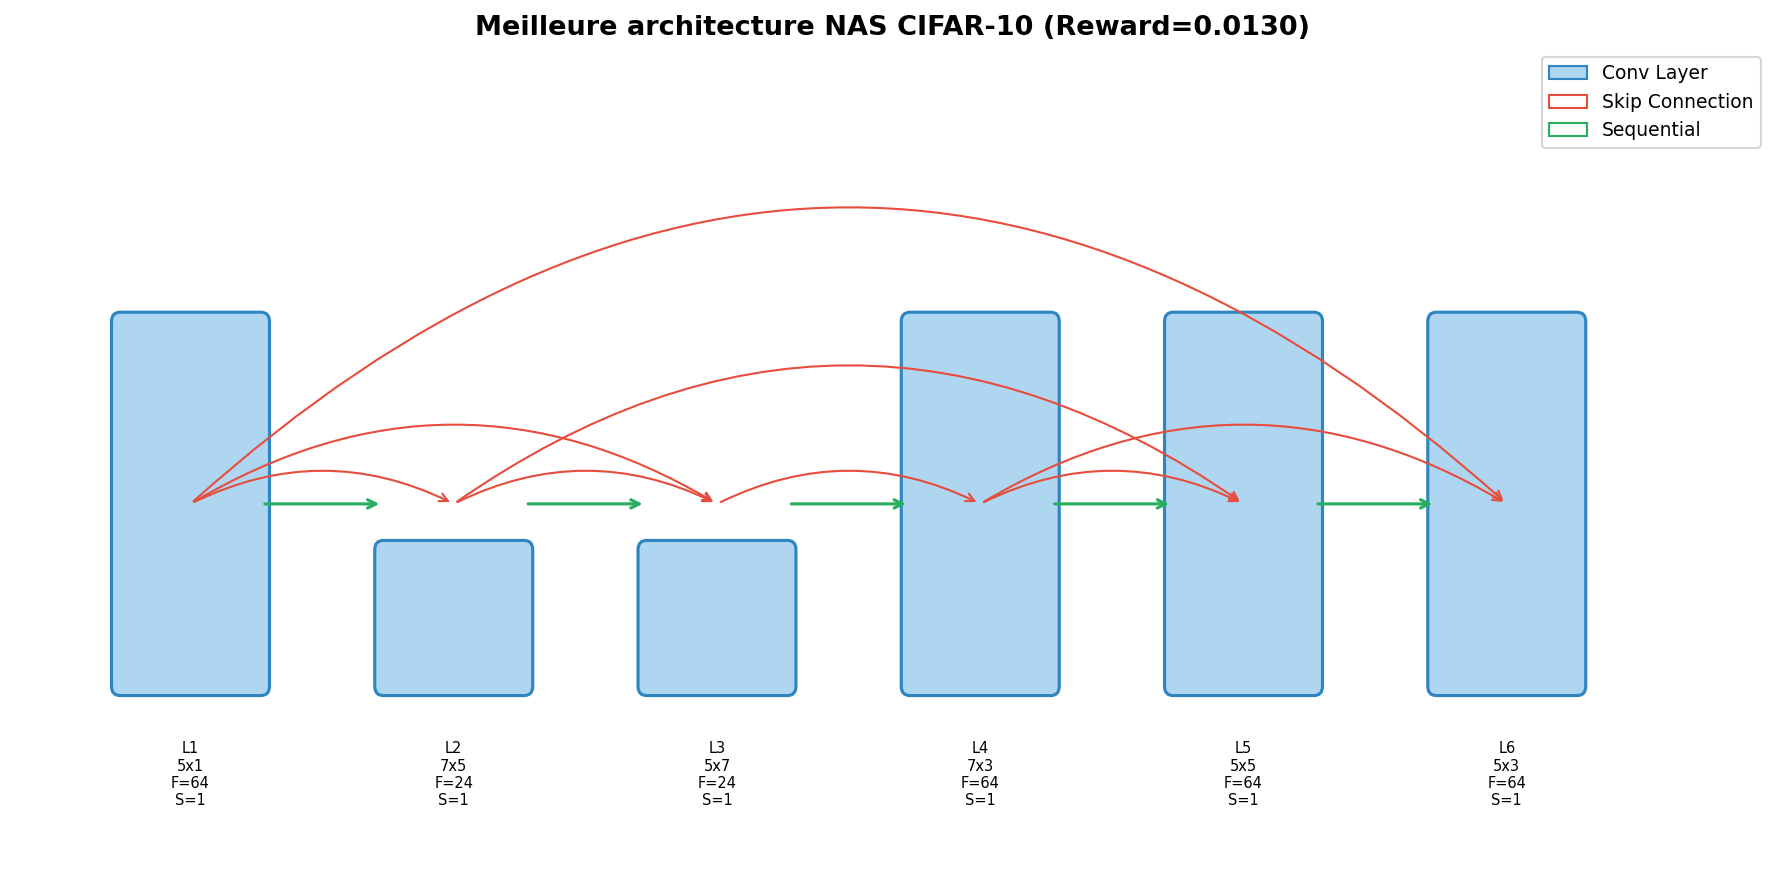


=== Meilleure cellule RNN (PTB) ===


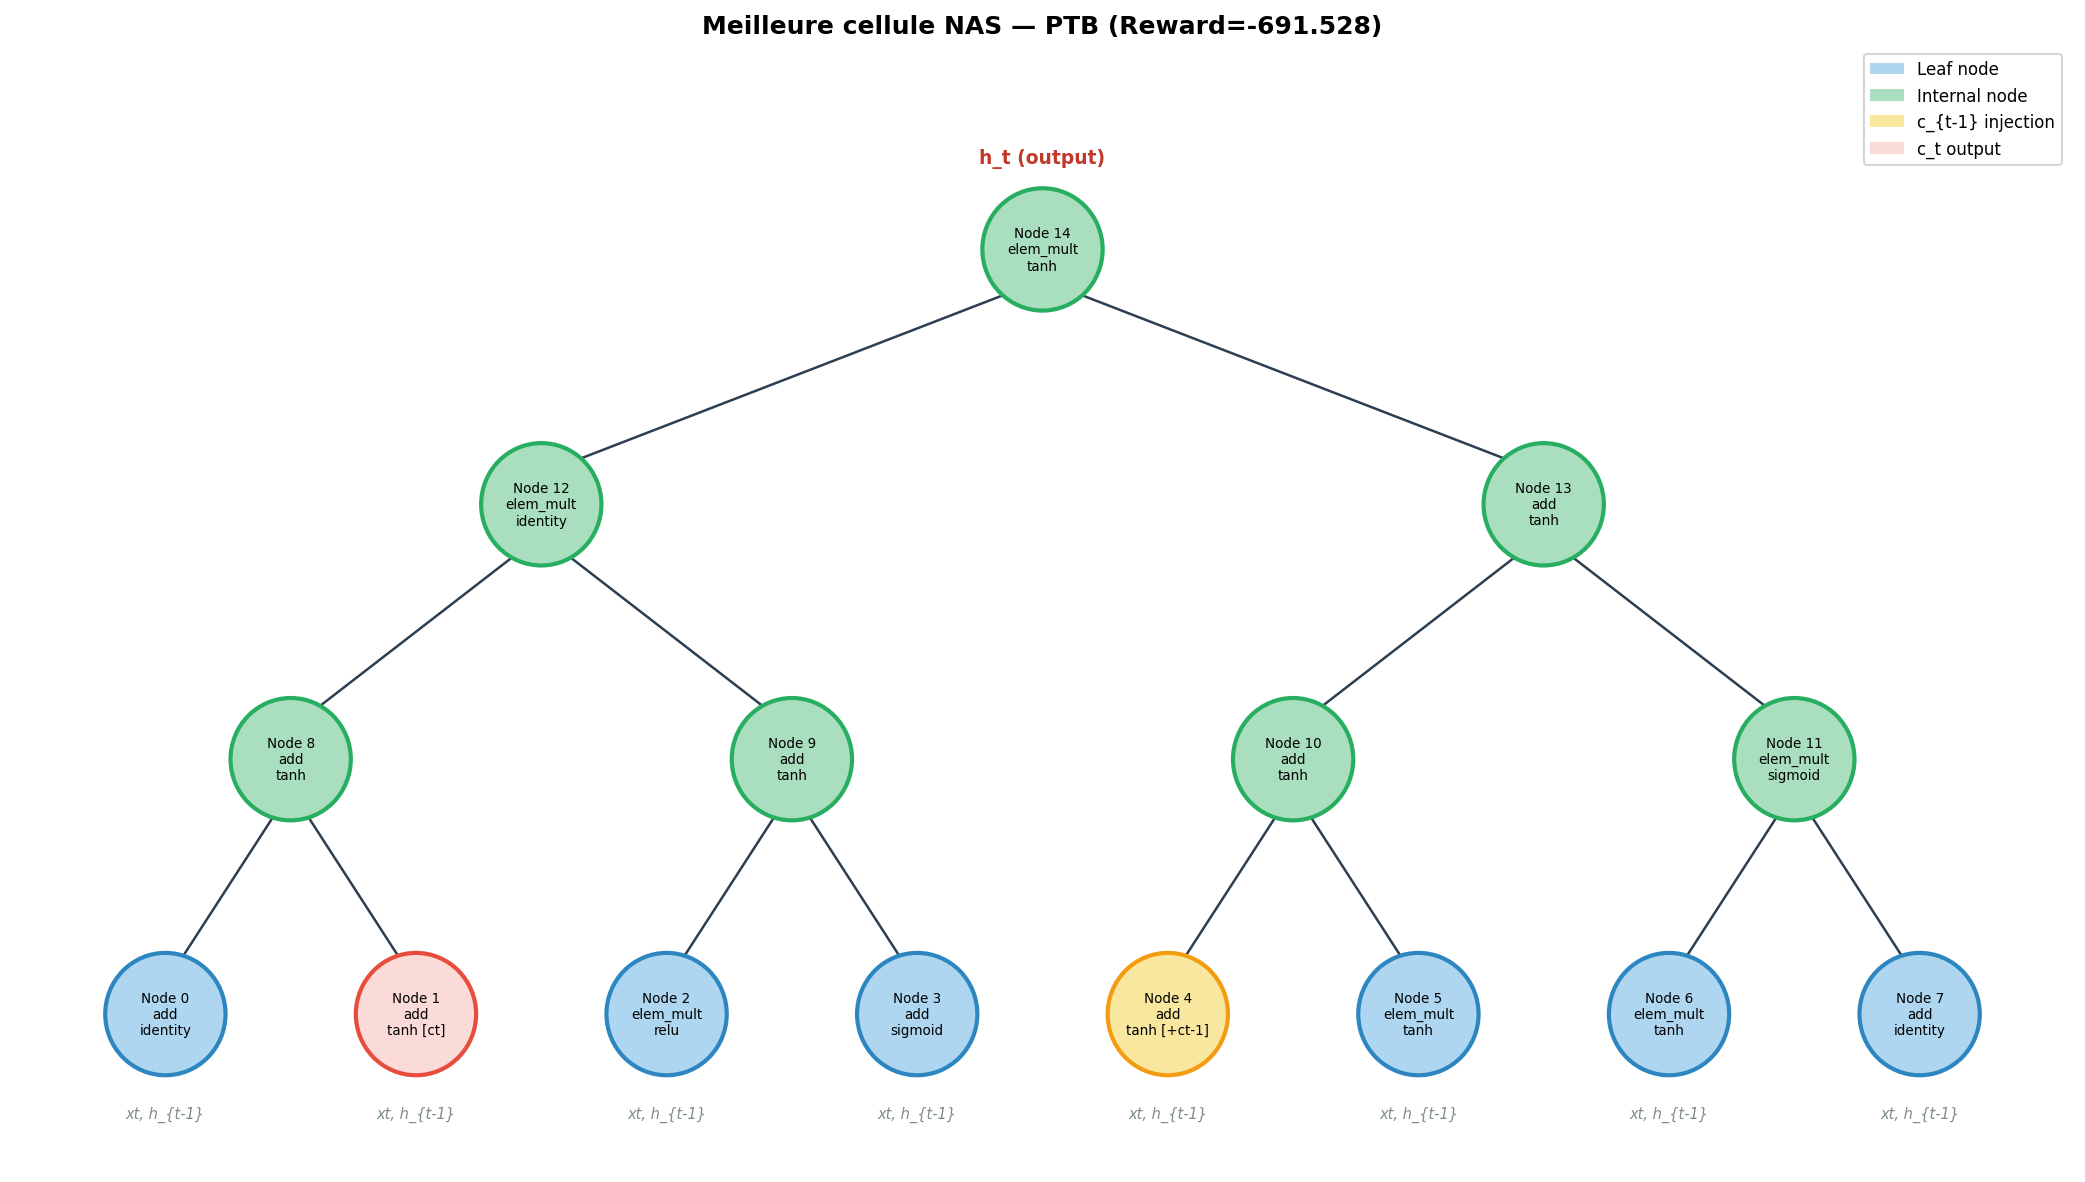


=== NAS vs Random — CIFAR-10 + PTB ===


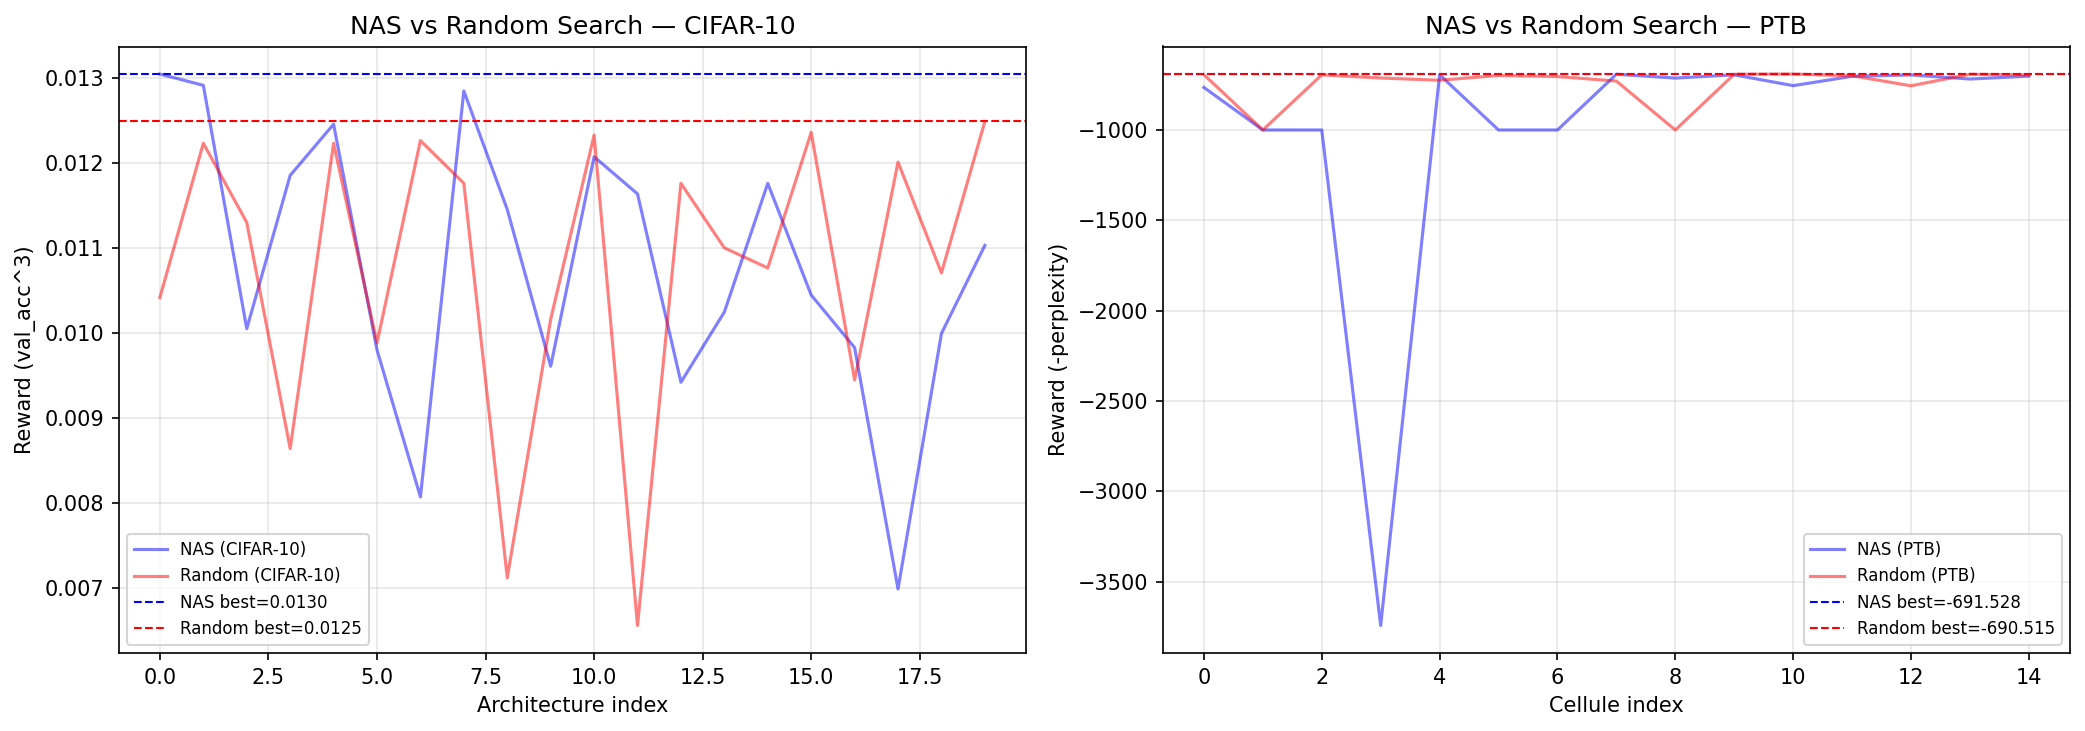


Toutes les visualisations affichées.
Le notebook est prêt. On peut maintenant générer le rapport PDF.


In [34]:
from IPython.display import Image, display, HTML

print("FINAL VISUALIZATIONS")
print("-" * 60)

figures = [
    ("Best CNN Architecture (CIFAR-10)",
     "./results/cifar10/best_architecture.png"),
    ("Best RNN Cell (PTB)",
     "./results/ptb/best_cell.png"),
    ("NAS vs Random — CIFAR-10 + PTB",
     "./results/nas_vs_random_summary.png"),
]

for title, path in figures:
    if os.path.exists(path):
        print(f"\n=== {title} ===")
        display(Image(path))
    else:
        print(f"[Not available] {path}")

print()
print("All visualizations displayed.")